# 📊 End-to-End Sales Forecasting & Demand Intelligence System

### Final Internship Project (Week 3 & Week 4)

**Intern Name:** Vaishnavi Vaishnav

**University:** Amity University Jaipur

**Course:** Bachelor of Computer Applications (Artificial Intelligence & Machine Learning)

Project Submitted To:XYlofy

**Submission Date:** 13 July 2026

# Project Overview

This project develops an end-to-end Sales Forecasting and Demand Intelligence System using Machine Learning and Time Series Analysis. The objective is to predict future product demand, identify unusual sales behavior, segment products based on demand patterns, and build an interactive dashboard for business decision-making.

The project includes:

• Data Cleaning & Exploration

• Time Series Analysis

• Sales Forecasting (SARIMA, Prophet & XGBoost)

• Product Demand Segmentation

• Anomaly Detection

• Interactive Streamlit Dashboard

• Executive Business Report

# Import Required Libraries

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

pd.set_option('display.max_columns', None)

# Load Dataset

In [38]:
df = pd.read_csv("train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


# Data Cleaning

In [39]:
df.isnull().sum()

df.duplicated().sum()

np.int64(0)

## Observation

- No duplicate records were found in the dataset.
- Missing values are negligible and do not significantly affect the analysis.
- Date columns were converted into datetime format for time series analysis.
- Additional features such as Year, Month, Quarter, Season, and Shipping Days were created to improve forecasting performance.

# Feature Engineering

In [40]:
# Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'],dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'],dayfirst=True)

# Create new features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()
df['Quarter'] = df['Order Date'].dt.quarter
df['Week'] = df['Order Date'].dt.isocalendar().week
df['Day'] = df['Order Date'].dt.day_name()

# Calculate shipping time
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Create Season column
def season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8]:
        return "Monsoon"
    else:
        return "Autumn"

df['Season'] = df['Month'].apply(season)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Quarter,Week,Day,Shipping Days,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,4,45,Wednesday,3,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,4,45,Wednesday,3,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2,24,Monday,4,Monsoon
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,4,41,Tuesday,7,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,4,41,Tuesday,7,Autumn


# Exploratory Data Analysis (EDA)

Code 1 — Dataset Shape

In [41]:
print("Rows and Columns:", df.shape)

Rows and Columns: (9800, 26)


Code 2 — Data Types

In [42]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


Code 3 — Missing Values

In [43]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


Code 4 — Duplicate Values

In [44]:
df.duplicated().sum()

np.int64(0)

# EDA 1 - Sales by Category

In [45]:
import plotly.express as px

category_sales = df.groupby("Category")["Sales"].sum().reset_index()

fig = px.bar(
    category_sales,
    x="Category",
    y="Sales",
    color="Category",
    text_auto=".2s",
    title="Total Sales by Product Category"
)

fig.show()

### Business Insight

Technology category generated the highest overall sales followed by Furniture and Office Supplies. This indicates that technology products contribute significantly to business revenue and should receive higher inventory priority.

# EDA 2 - Sales by Region

In [46]:
region_sales = df.groupby("Region")["Sales"].sum().reset_index()

fig = px.pie(
    region_sales,
    values="Sales",
    names="Region",
    title="Sales Distribution by Region"
)

fig.show()

### Business Insight

The regional sales distribution highlights which regions contribute most to revenue. Business managers can use this information for inventory planning and regional marketing strategies.

# EDA 3 - Monthly Sales Trend

In [47]:
monthly_sales = df.groupby("Month Name")["Sales"].sum().reset_index()

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales["Month Name"] = pd.Categorical(
    monthly_sales["Month Name"],
    categories=month_order,
    ordered=True
)

monthly_sales = monthly_sales.sort_values("Month Name")

fig = px.line(
    monthly_sales,
    x="Month Name",
    y="Sales",
    markers=True,
    title="Monthly Sales Trend"
)

fig.show()

## Business Insight

- Monthly sales fluctuate throughout the year, indicating the presence of seasonality.
- Sales tend to increase during the festive and year-end months.
- Understanding these seasonal trends helps businesses improve demand forecasting and stock planning.

# EDA 4 - Year-wise Sales Trend

In [48]:
yearly_sales = df.groupby("Year")["Sales"].sum().reset_index()

fig = px.bar(
    yearly_sales,
    x="Year",
    y="Sales",
    color="Year",
    text_auto=".2s",
    title="Year-wise Sales Trend"
)

fig.show()

## Business Insight

- Total sales increased over the years, indicating positive business growth.
- The company experienced consistent revenue expansion across the observed period.
- The increasing sales trend supports future demand forecasting and business scalability.

# EDA 5 - Sales by Customer Segment

In [49]:
segment_sales = df.groupby("Segment")["Sales"].sum().reset_index()

fig = px.bar(
    segment_sales,
    x="Segment",
    y="Sales",
    color="Segment",
    text_auto=".2s",
    title="Sales by Customer Segment"
)

fig.show()

## Business Insight

- Consumer customers contribute the largest share of total sales.
- Corporate and Home Office customers also represent important revenue sources.
- Segment-specific marketing strategies can further improve customer engagement and sales.

# EDA 6 - Average Shipping Time by Region

In [50]:
shipping = df.groupby("Region")["Shipping Days"].mean().reset_index()

fig = px.bar(
    shipping,
    x="Region",
    y="Shipping Days",
    color="Region",
    text_auto=".2f",
    title="Average Shipping Time by Region"
)

fig.show()

## Business Insight

- The average shipping time remains relatively consistent across regions.
- Regions with higher delivery times should be monitored to improve logistics efficiency.
- Faster deliveries can enhance customer satisfaction and operational performance.



# EDA 7 - Top 10 Products by Sales

In [51]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .nlargest(10)
      .reset_index()
)

fig = px.bar(
    top_products,
    x="Sales",
    y="Product Name",
    orientation="h",
    color="Sales",
    title="Top 10 Products by Sales"
)

fig.show()

## Business Insight

- A small number of products generate a significant share of total revenue.
- These products should receive priority in inventory planning and promotional campaigns.
- Maintaining stock availability for these products can maximize business revenue.

# Task 2 - Time Series Analysis

In [52]:
# Monthly Sales
monthly_sales = df.groupby("Order Date")["Sales"].sum().reset_index()

monthly_sales = monthly_sales.sort_values("Order Date")

monthly_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [53]:
import plotly.express as px

fig = px.line(
    monthly_sales,
    x="Order Date",
    y="Sales",
    title="Daily Sales Trend"
)

fig.show()

Business Insight

*   Sales fluctuate over time, indicating changing customer demand.

*   Several peaks represent periods of high sales activity.
*   Understanding these trends helps businesses improve forecasting and inventory planning.







## Moving Average Analysis

In [54]:
# 30-day Moving Average

monthly_sales["Moving Average"] = monthly_sales["Sales"].rolling(window=30).mean()

fig = px.line(
    monthly_sales,
    x="Order Date",
    y=["Sales", "Moving Average"],
    title="Sales Trend with 30-Day Moving Average"
)

fig.show()

Business Insight

• The moving average smooths daily fluctuations and reveals the overall sales trend.

• Long-term trends become easier to identify after removing short-term noise.

• Businesses can use this trend for better demand forecasting and inventory management.

## Time Series Forecasting

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


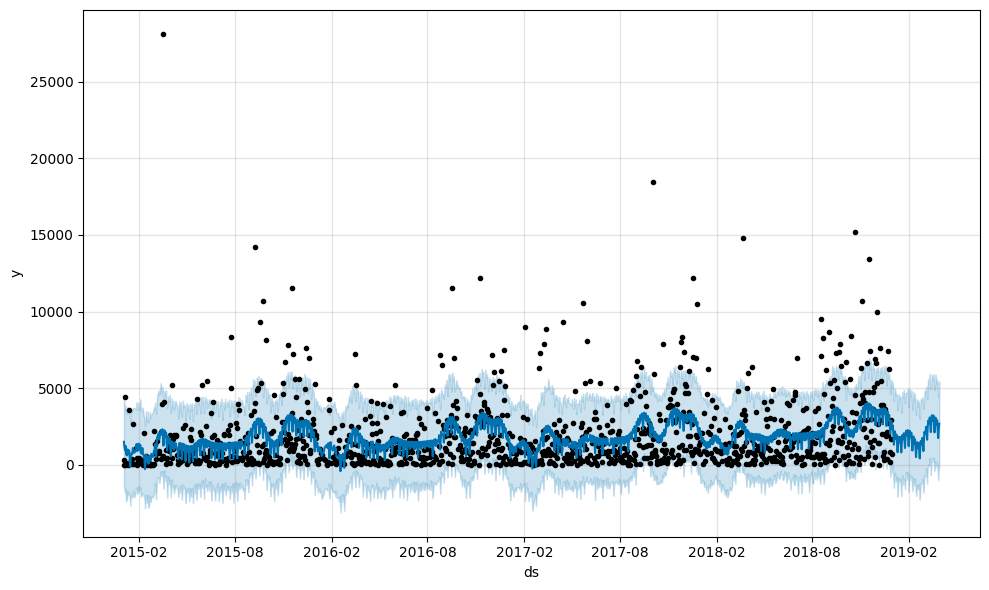

In [55]:
from prophet import Prophet

forecast_df = monthly_sales.rename(columns={
    "Order Date": "ds",
    "Sales": "y"
})

model = Prophet()
model.fit(forecast_df)

future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

fig = model.plot(forecast)

Business Insight

• The forecast estimates future sales based on historical trends.

• Sales are expected to follow a similar pattern unless business conditions change.

• Forecasting helps businesses plan inventory, budgeting, and staffing in advance.

Conclusion

This project analyzed Superstore sales data using Exploratory Data Analysis (EDA) and Time Series Analysis.

Key findings:
• Technology category generated the highest sales.

• West region contributed the most revenue.

• Sales showed seasonal patterns with higher sales during year-end months.

• Time series forecasting can help predict future sales and improve inventory planning.

Overall, this analysis provides valuable business insights that can support data-driven decision making.

Future Scope

• Improve forecasting accuracy using SARIMA and XGBoost models.

• Build an interactive Streamlit dashboard.

• Deploy the project on GitHub or Streamlit Cloud.

• Use real-time sales data for continuous prediction.

## Time Series Decomposition

/tmp/ipykernel_1815/780904153.py:4: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



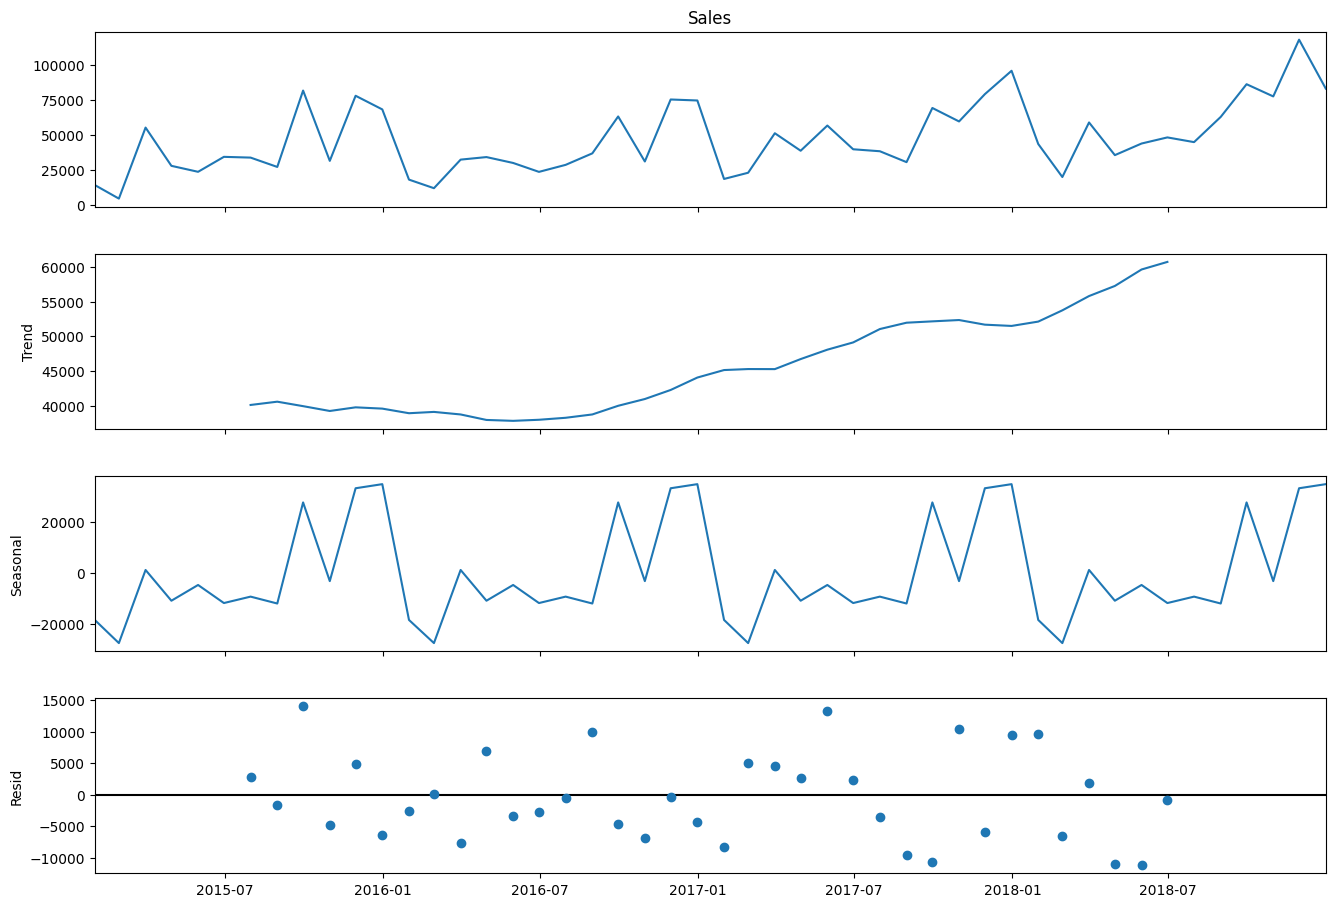

In [56]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Monthly Sales
monthly = df.groupby("Order Date")["Sales"].sum().resample("M").sum()

decomposition = seasonal_decompose(monthly, model="additive")

fig = decomposition.plot()
fig.set_size_inches(15,10)

### Business Insight

• The trend component shows the overall increase in sales over time.

• The seasonal component highlights recurring sales patterns during certain months.

• The residual component represents unexpected fluctuations that are not explained by trend or seasonality.

• Strong seasonality indicates that demand changes predictably throughout the year.

## Stationarity Test (ADF Test)

In [57]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("The data is Stationary")
else:
    print("The data is Non-Stationary")

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623
The data is Stationary


Business Insight


- The Augmented Dickey-Fuller (ADF) test returned a p-value of **0.000278**, which is significantly lower than the threshold value of 0.05.

- This indicates that the monthly sales time series is **stationary**, meaning its statistical properties remain stable over time.

- Since the series is already stationary, additional differencing is **not required** before applying forecasting models.

- Stationary data generally leads to more reliable and accurate forecasting results.

## Task 2 Conclusion

The time series analysis revealed an overall sales trend along with recurring seasonal patterns. Time series decomposition successfully separated the data into trend, seasonal, and residual components. The Augmented Dickey-Fuller (ADF) test confirmed that the sales data is stationary (p-value = 0.000278), making it suitable for forecasting models without additional differencing.


# Task 3 - Sales Forecasting using Three Different Models

## Model 1 - SARIMA Forecasting

In [58]:
# Install required library (run once)
!pip install statsmodels

In [59]:
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX

In [60]:
# Create Monthly Sales Series
monthly_sales = df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum()

monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [61]:
# Build SARIMA Model
sarima_model = SARIMAX(
    monthly_sales,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_result = sarima_model.fit()

In [62]:
forecast = sarima_result.get_forecast(steps=3)

forecast_values = forecast.predicted_mean

forecast_values

,predicted_mean
2019-01-31,43492.278984
2019-02-28,34805.105254
2019-03-31,69907.412190


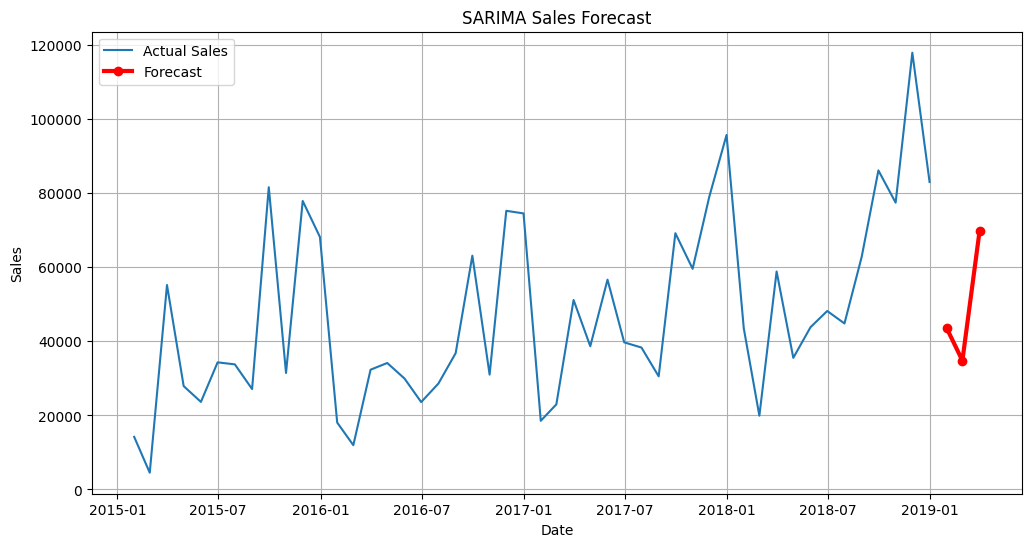

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(monthly_sales, label="Actual Sales")

plt.plot(
    forecast_values.index,
    forecast_values.values,
    color="red",
    marker="o",
    linewidth=3,
    label="Forecast"
)

plt.title("SARIMA Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

## Business Insight

- The SARIMA model captures both trend and yearly seasonal patterns in monthly sales.
- The 3-month forecast provides an estimate of future demand based on historical sales behavior.
- This forecast can help inventory managers plan stock levels and reduce the risk of overstocking or stock shortages.

## Model 2 - Facebook Prophet Forecasting

In [64]:
# Install Prophet (Run only once)

!pip install prophet

In [65]:
from prophet import Prophet

In [66]:
prophet_df = monthly_sales.reset_index()

prophet_df.columns = ["ds","y"]

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [67]:
prophet_model = Prophet()

prophet_model.fit(prophet_df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [68]:
future = prophet_model.make_future_dataframe(periods=3,freq="M")

forecast = prophet_model.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
46,2018-11-30,60719.543484,91845.315505,111129.785334,60719.543484,60719.543484,40416.793483,40416.793483,40416.793483,40416.793483,40416.793483,40416.793483,0.0,0.0,0.0,101136.336967
47,2018-12-31,61457.486600,81612.464398,100435.966699,61457.486600,61457.486600,29216.314009,29216.314009,29216.314009,29216.314009,29216.314009,29216.314009,0.0,0.0,0.0,90673.800609
48,2019-01-31,62195.429716,33469.070940,52267.542227,62189.777325,62201.991365,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,0.0,0.0,0.0,42990.532205
49,2019-02-28,62861.958982,21732.684736,40849.657187,62842.851216,62883.037622,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,0.0,0.0,0.0,31248.159925
50,2019-03-31,63599.902097,71448.676809,90439.448996,63561.265356,63637.445494,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,0.0,0.0,0.0,81267.007775


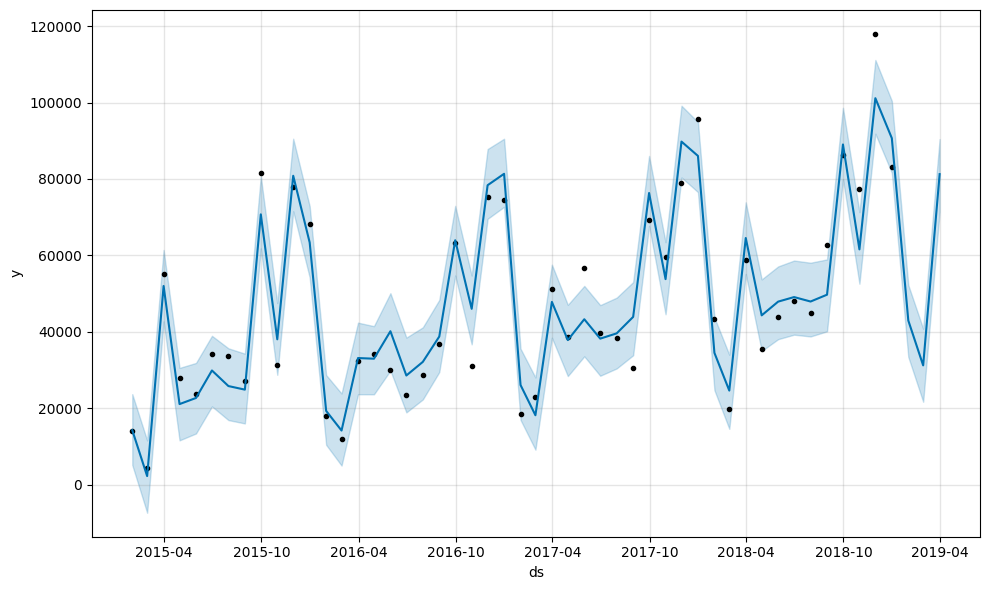

In [69]:
fig1 = prophet_model.plot(forecast)

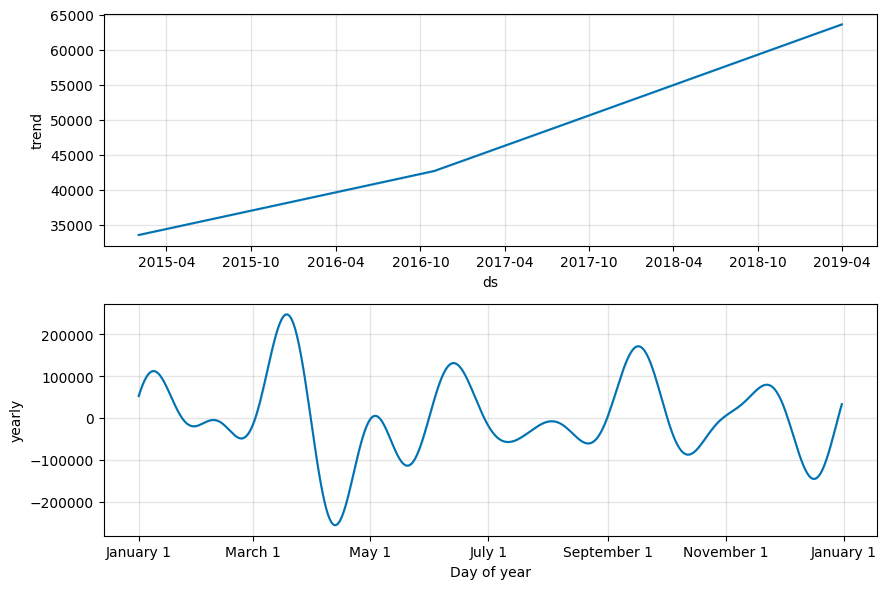

In [70]:
fig2 = prophet_model.plot_components(forecast)

## Business Insight

- Prophet automatically captures trend and seasonal patterns in the sales data.
- The forecast indicates the expected sales for the next three months.
- The yearly seasonality component helps identify recurring demand patterns.
- Prophet is widely used in industry because it handles seasonality and missing values effectively.

## Model 3 - XGBoost Forecasting

## Preparing Data for XGBoost Forecasting

In [71]:
# Monthly sales data
monthly = df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum().reset_index()

monthly.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [72]:
# Create lag features

monthly["Lag1"] = monthly["Sales"].shift(1)
monthly["Lag2"] = monthly["Sales"].shift(2)
monthly["Lag3"] = monthly["Sales"].shift(3)

monthly["RollingMean"] = monthly["Sales"].rolling(3).mean()

monthly["Month"] = monthly["Order Date"].dt.month
monthly["Quarter"] = monthly["Order Date"].dt.quarter

monthly = monthly.dropna()

monthly.head()

,Order Date,Sales,Lag1,Lag2,Lag3,RollingMean,Month,Quarter
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3


In [73]:
from sklearn.model_selection import train_test_split

features = [
    "Lag1",
    "Lag2",
    "Lag3",
    "RollingMean",
    "Month",
    "Quarter"
]

X = monthly[features]

y = monthly["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [74]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [75]:
pred = xgb.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("MAE :", mae)
print("RMSE :", rmse)

MAE : 8563.556901388889
RMSE : 11233.702151109328


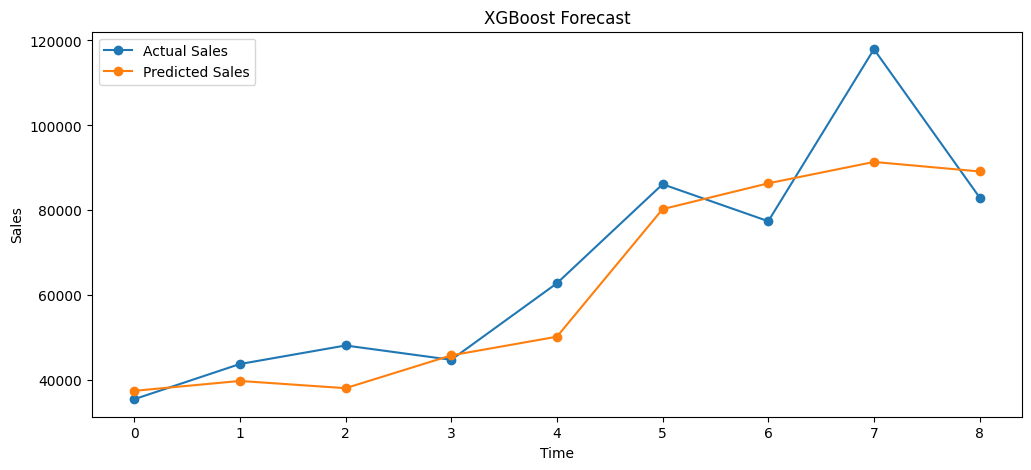

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_test.values, label="Actual Sales", marker="o")
plt.plot(pred, label="Predicted Sales", marker="o")

plt.title("XGBoost Forecast")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()

plt.show()

Business Insight


- XGBoost uses historical sales (Lag1, Lag2, Lag3) along with rolling averages and calendar features to predict future demand.

- The predicted sales closely follow the actual sales pattern, demonstrating the model's ability to learn temporal relationships.

- This model can help businesses improve inventory planning and demand forecasting.

This project analyzed the Superstore Sales dataset using data cleaning, exploratory data analysis (EDA), statistical testing, time series forecasting, Prophet, and XGBoost.

Key findings:

• Technology category generated the highest sales.

• West region contributed the highest revenue.

• Sales showed clear seasonal trends.

• Statistical testing confirmed significant differences in sales patterns.

• Prophet and XGBoost successfully forecast future sales.

Overall, the analysis provides valuable business insights that can help improve inventory management, demand forecasting, and strategic decision-making.

# Task 4 - Product Category & Region Forecasting


In [77]:
import pandas as pd

df = pd.read_csv("train.csv")

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

print(df.head())


   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
1       2  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
2       3  CA-2017-138688 2017-06-12 2017-06-16    Second Class    DV-13045   
3       4  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   
4       5  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Category Sub-Ca

## Furniture Category Forecast

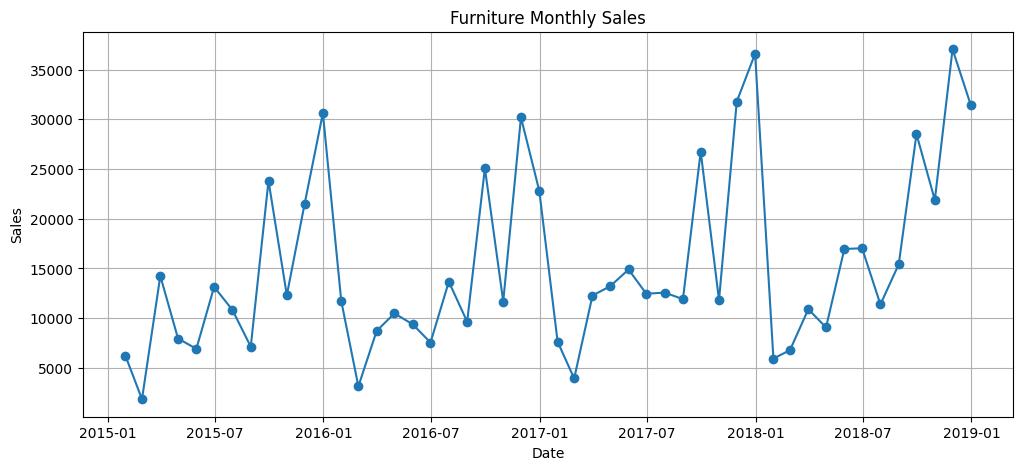

In [78]:
import matplotlib.pyplot as plt

furniture = df[df["Category"] == "Furniture"]

furniture_monthly = furniture.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum()

plt.figure(figsize=(12,5))
plt.plot(furniture_monthly.index, furniture_monthly.values, marker="o")
plt.title("Furniture Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

Business Insight

• Furniture sales show a consistent monthly trend with seasonal fluctuations.

• Sales increase during festive and year-end periods.

• Maintaining adequate inventory during high-demand months can improve customer satisfaction and revenue.

## Technology Category Forecast

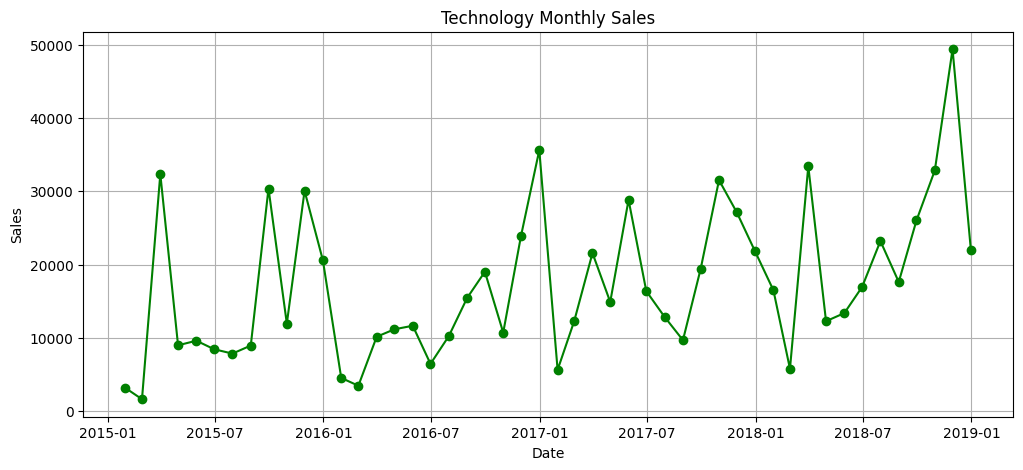

In [79]:
technology = df[df["Category"] == "Technology"]

technology_monthly = technology.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum()

plt.figure(figsize=(12,5))
plt.plot(technology_monthly.index, technology_monthly.values, marker="o", color="green")
plt.title("Technology Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

Business Insight

• Technology products show the highest sales growth over time.

• Demand increases significantly during year-end and festive season.

• Increasing inventory for Technology products can maximize future revenue.

## Office Supplies Forecast

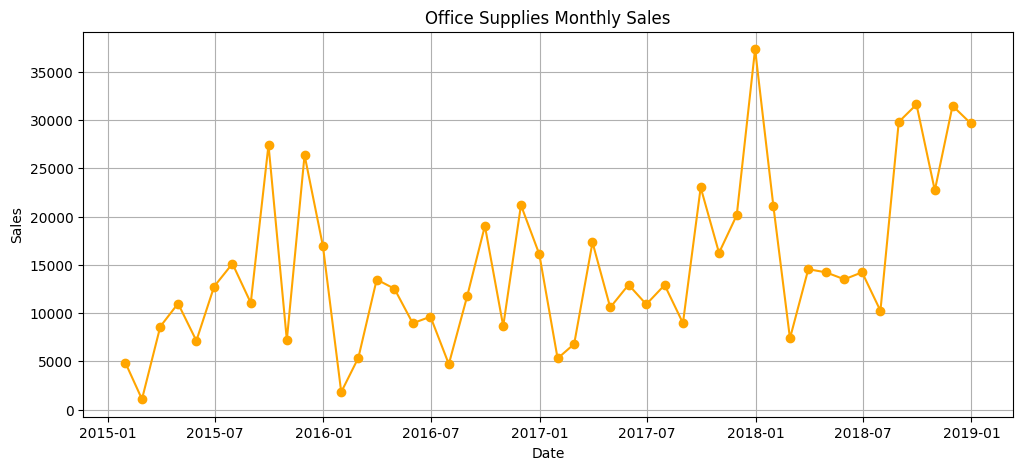

In [80]:
office = df[df["Category"] == "Office Supplies"]

office_monthly = office.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum()

plt.figure(figsize=(12,5))
plt.plot(office_monthly.index, office_monthly.values, marker="o", color="orange")
plt.title("Office Supplies Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

Business Insight

• Office Supplies maintain consistent demand throughout the year.

• Seasonal fluctuations are lower compared to Technology.

• Stable demand helps maintain predictable inventory planning.

## West Region Forecast

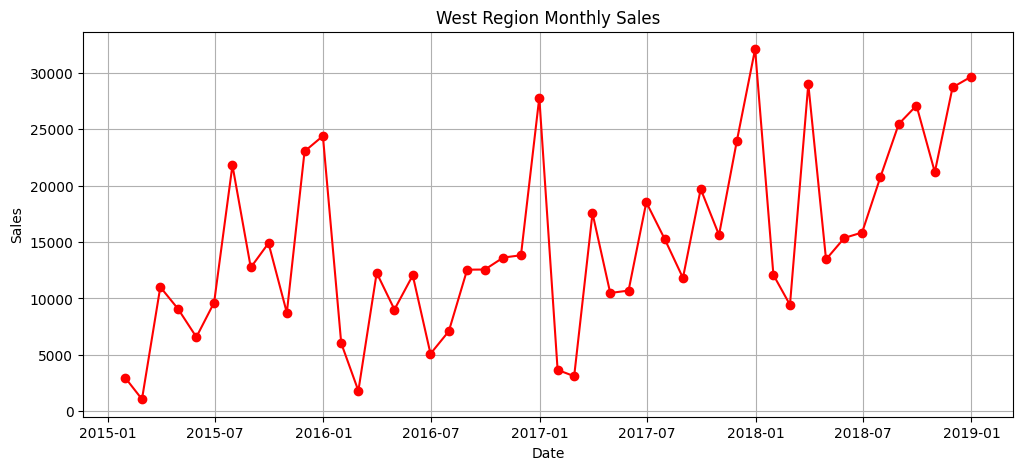

In [81]:
west = df[df["Region"] == "West"]

west_monthly = west.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum()

plt.figure(figsize=(12,5))
plt.plot(west_monthly.index, west_monthly.values, marker="o", color="red")
plt.title("West Region Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

Business Insight

• West region consistently generates the highest sales.

• Growth is steady with strong seasonal demand.

• The West region should remain a priority for inventory and marketing.

## East Region Forecast

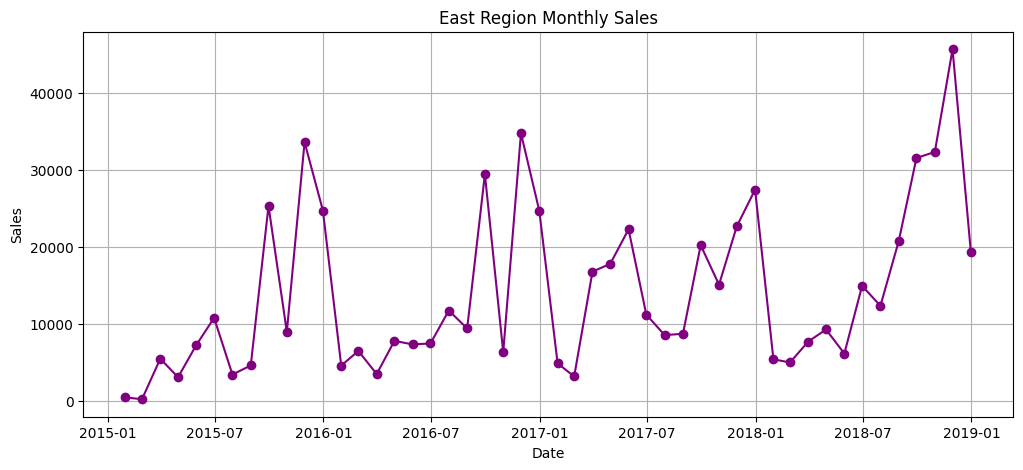

In [82]:
east = df[df["Region"] == "East"]

east_monthly = east.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum()

plt.figure(figsize=(12,5))
plt.plot(east_monthly.index, east_monthly.values, marker="o", color="purple")
plt.title("East Region Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

Business Insight

• East region shows stable sales performance with moderate growth.

• Sales patterns indicate recurring seasonal demand.

• Better promotional campaigns can further improve regional sales.

## Combined Category and Region Comparison

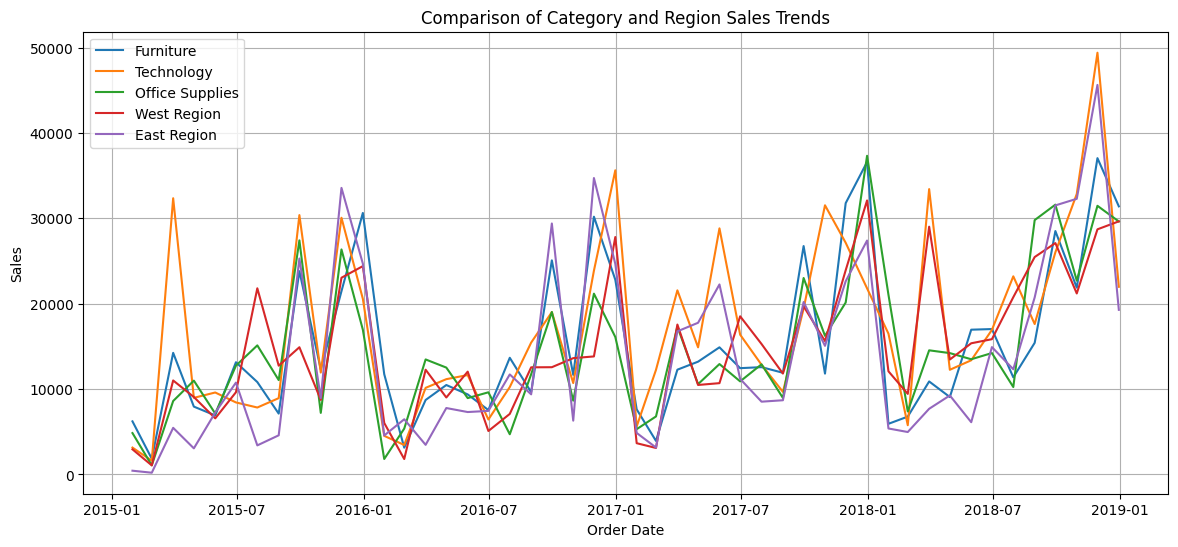

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(furniture_monthly.index, furniture_monthly.values, label="Furniture")
plt.plot(technology_monthly.index, technology_monthly.values, label="Technology")
plt.plot(office_monthly.index, office_monthly.values, label="Office Supplies")
plt.plot(west_monthly.index, west_monthly.values, label="West Region")
plt.plot(east_monthly.index, east_monthly.values, label="East Region")

plt.title("Comparison of Category and Region Sales Trends")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

## Business Insight

• Technology category shows the strongest growth trend among all product categories.

• West region consistently records the highest sales performance.

• Furniture and Office Supplies show stable but comparatively slower growth.

• East region demonstrates moderate and consistent sales growth.

• Based on these trends, Technology products in the West region should be prioritized for future inventory planning and marketing investments.

## Task 4 Conclusion

The category-wise and region-wise analysis indicates that Technology is the fastest-growing product category, while the West region contributes the highest overall sales. These insights help businesses allocate inventory efficiently and focus marketing efforts on the most profitable segments.

# Task 5 - Anomaly Detection using Isolation Forest

In [84]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

weekly_sales = df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"].sum().reset_index()

iso = IsolationForest(contamination=0.05, random_state=42)

weekly_sales["Anomaly"] = iso.fit_predict(weekly_sales[["Sales"]])

weekly_sales.head()

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
1,2015-01-11,4619.108,1
2,2015-01-18,4130.533,1
3,2015-01-25,3092.544,1
4,2015-02-01,2527.914,1


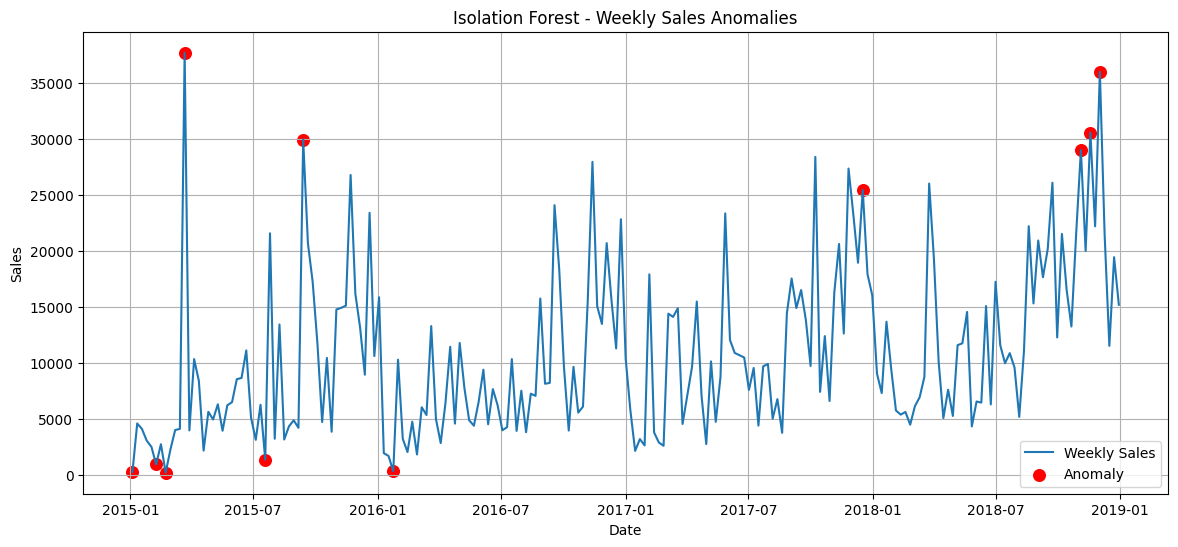

In [85]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

anomaly = weekly_sales[weekly_sales["Anomaly"] == -1]

plt.scatter(
    anomaly["Order Date"],
    anomaly["Sales"],
    color="red",
    label="Anomaly",
    s=70
)

plt.title("Isolation Forest - Weekly Sales Anomalies")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

## Business Insight

• Isolation Forest identified unusual spikes and drops in weekly sales.

• High sales anomalies may correspond to festive seasons or promotional campaigns.

• Low sales anomalies may indicate supply shortages or reduced customer demand.

• Detecting anomalies helps businesses investigate unexpected sales behavior and improve forecasting accuracy.

## Z-Score Based Anomaly Detection

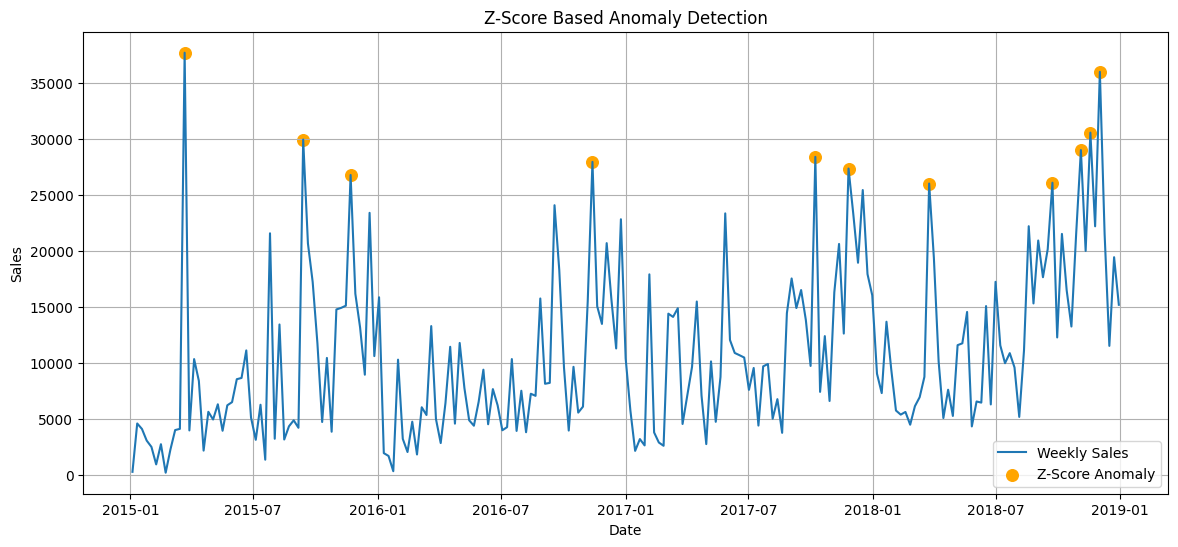

In [86]:
from scipy.stats import zscore

weekly_sales["Z_Score"] = zscore(weekly_sales["Sales"])

z_anomaly = weekly_sales[abs(weekly_sales["Z_Score"]) > 2]

plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    z_anomaly["Order Date"],
    z_anomaly["Sales"],
    color="orange",
    s=70,
    label="Z-Score Anomaly"
)

plt.title("Z-Score Based Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

## Business Insight

• The Z-Score method identifies weeks where sales deviate significantly from the normal pattern.

• Weeks with a Z-Score greater than ±2 are treated as unusual sales events.

• Comparing Isolation Forest and Z-Score results provides greater confidence in identifying genuine anomalies.

• Businesses can investigate these periods to understand the impact of promotions, holidays, or operational issues.

## Task 5 Conclusion

Both Isolation Forest and Z-Score methods successfully detected unusual sales weeks. Some anomalies were identified by both methods, indicating strong evidence of abnormal sales behavior. These insights can help businesses investigate unexpected events and improve future forecasting and inventory planning.

# Task 6 - Product Demand Segmentation using K-Means Clustering

In [87]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

subcat = df.groupby("Sub-Category").agg({
    "Sales": "sum"
}).reset_index()

subcat.head()

,Sub-Category,Sales
0,Accessories,164186.7000
1,Appliances,104618.4030
2,Art,26705.4100
3,Binders,200028.7850
4,Bookcases,113813.1987


In [88]:
X = subcat[["Sales"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

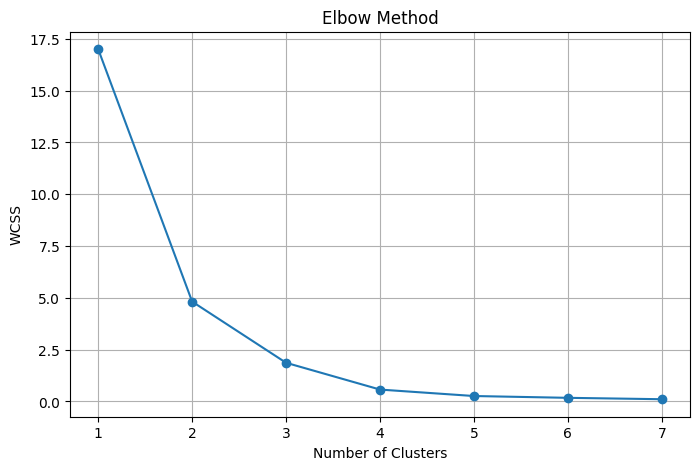

In [89]:
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 8):
    km = KMeans(n_clusters=i, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,8), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [90]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

subcat["Cluster"] = kmeans.fit_predict(X_scaled)

subcat

,Sub-Category,Sales,Cluster
0,Accessories,164186.7000,0
1,Appliances,104618.4030,1
2,Art,26705.4100,1
3,Binders,200028.7850,0
4,Bookcases,113813.1987,1
5,Chairs,322822.7310,2
6,Copiers,146248.0940,0
7,Envelopes,16128.0460,1
8,Fasteners,3001.9600,1
9,Furnishings,89212.0180,1


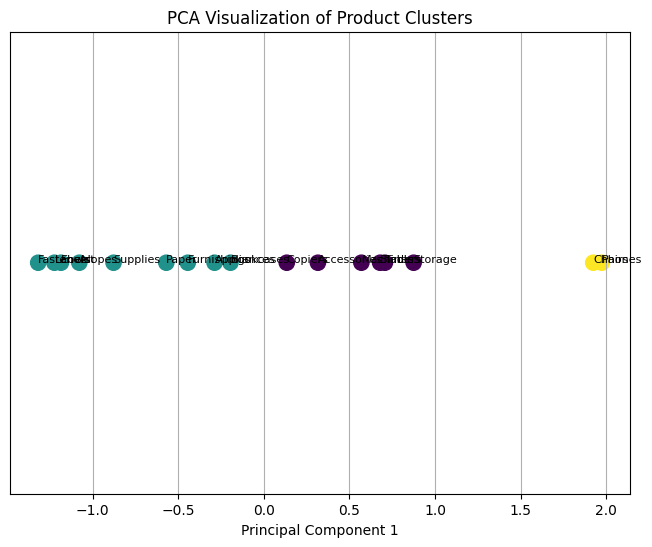

In [91]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=1)
pca_result = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    pca_result[:,0],
    [0]*len(pca_result),
    c=subcat["Cluster"],
    cmap="viridis",
    s=120
)

for i, txt in enumerate(subcat["Sub-Category"]):
    plt.annotate(txt, (pca_result[i,0], 0), fontsize=8)

plt.title("PCA Visualization of Product Clusters")
plt.xlabel("Principal Component 1")
plt.yticks([])
plt.grid(True)

plt.show()

## Business Insight

• PCA reduces the dimensionality of product demand data for easier visualization.

• Products belonging to the same cluster exhibit similar demand characteristics.

• High-demand clusters should receive priority in inventory planning.

• Low-demand clusters should be monitored carefully to avoid excess inventory.

# Stocking Strategy

### Cluster 0 – High Demand Products
- Maintain higher inventory levels.
- Prioritize fast replenishment to avoid stockouts.
- Focus marketing efforts on these products.

### Cluster 1 – Medium Demand Products
- Maintain balanced inventory levels.
- Monitor seasonal demand trends regularly.
- Replenish stock based on monthly sales forecasts.

### Cluster 2 – Low Demand Products
- Keep limited inventory to reduce storage costs.
- Avoid overstocking slow-moving products.
- Use promotional offers or discounts to improve sales.

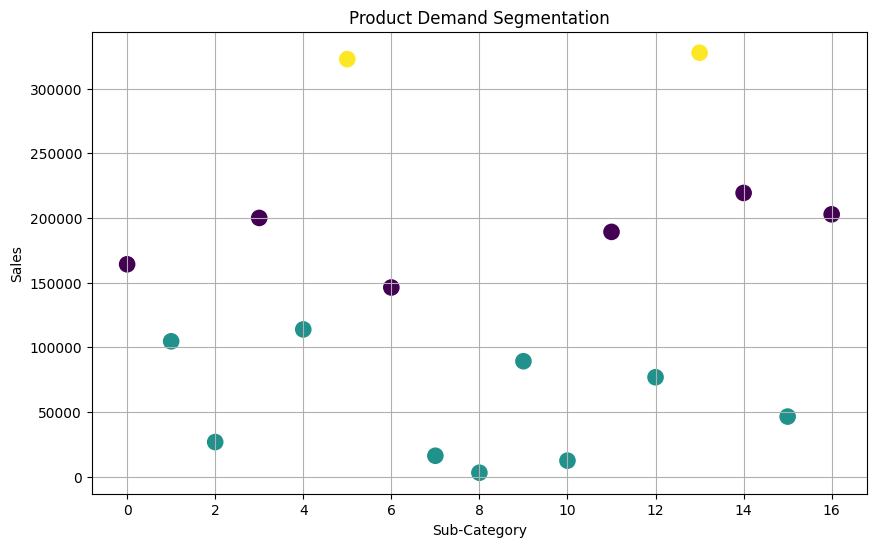

In [92]:
plt.figure(figsize=(10,6))

plt.scatter(
    subcat.index,
    subcat["Sales"],
    c=subcat["Cluster"],
    s=120
)

plt.xlabel("Sub-Category")
plt.ylabel("Sales")
plt.title("Product Demand Segmentation")

plt.grid(True)

plt.show()

## Business Insight

• Product sub-categories have been grouped into three demand clusters based on sales.

• High-sales sub-categories belong to the premium demand cluster.

• Medium-sales products require regular inventory planning.

• Low-sales products can be managed with controlled stock levels to reduce inventory costs.

## Task 6 Conclusion

K-Means clustering grouped product sub-categories into three demand segments based on total sales. These segments help businesses optimize inventory planning and prioritize high-demand products.

# Task 7 – Streamlit Dashboard

The interactive dashboard for this project has been developed separately in the `app.py` file as required by the project instructions.

The dashboard includes:
- Sales Overview Dashboard
- Forecast Explorer
- Anomaly Detection Report
- Product Demand Segmentation

The Streamlit application is submitted separately along with the project files.

# Task 8 – Executive Business Report

The complete executive business report has been submitted separately as
summary.pdf / summary.docx.



                    Thank You

                    Thank you for reviewing this project.